# Certification — `STL_Healpix_Kernel_Torch`: interface parity with the 2D kernel

This notebook certifies **steps 1 to 5** of the HEALPix port:

1. `Base_DataClass` and `ST_Operator` made data-type agnostic
   (`NDIM_PIX`, `_infer_N0`, no hard-coded pixel axes in the slicing);
2. `STL_Healpix_Kernel_Torch` derived from `Base_DataClass`
   (`pbc`, `dg`, `N0`, `conv_history`, `cell_ids`, `divide`, `get_ST_op`);
3. the statistics moved onto the wavelet operator
   (`mean`, `square_mean`, `cov`, `standardize`, `unstandardize`,
   `_compute_and_store_cross_cov`, `j_to_dg`, `mask_full_res`, `downsample`);
4. `get_CS_op()` — the angular power spectrum, built on the differentiable
   spherical harmonic transform of `healpix-analyse`
   (`HEALPixSHT`: `map2alm` / `alm2map` / `anafast`);
5. `mask_full_res` — the per-layer invalid masks and the reweighting maps that
   keep masked data usable, the spherical counterpart of the planar
   `_build_reweighting_maps_and_scattering_layer_masks`;
6. `Synthesis` made data-type agnostic, so a field can be synthesised on the
   sphere from its scattering statistics.

**Out of scope at this stage** (see the closing section):

* the deconvolution of the mask-induced mode coupling: the partial-sky
  spectrum is a pseudo-C_ell, with no MASTER matrix.

In [1]:
import os
import sys
import warnings

import numpy as np
import torch
import healpy as hp
import matplotlib.pyplot as plt

# --- walk up to the repository root (the directory holding STL_main) ---
ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "STL_main")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        raise RuntimeError("STL_main directory not found above %s" % os.getcwd())
    ROOT = parent
sys.path.insert(0, ROOT)

DATA_TEST_PATH = os.path.join(ROOT, "data", "test")
print("Repository root:", ROOT)

warnings.filterwarnings("ignore", category=UserWarning)

from STL_main.ST_Operator import ST_Operator
from STL_main.STL_Healpix_Kernel_Torch import (
    STL_Healpix_Kernel_Torch as DataClass,
    WaveletOperatorHealpixKernel_torch,
)

torch.manual_seed(0)
np.random.seed(0)

Repository root: /home/jovyan/STL-Dev


## 0. Test map

The repository LSS map is used when present, otherwise a Gaussian realisation of
a power-law spectrum. **NESTED** ordering in both cases, as the HEALPix
downsampling requires it.

map: /home/jovyan/kappa_gen.fits | nside = 64 | Npix = (49152,)


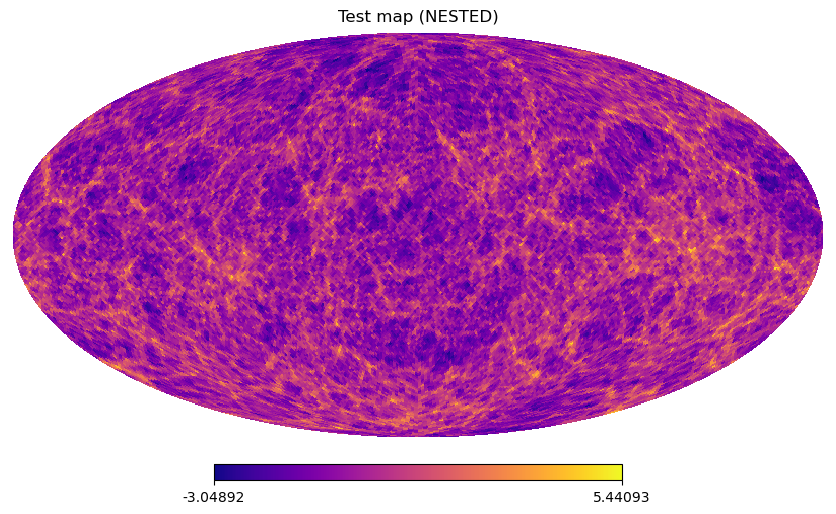

In [2]:
import healpy as hp
NSIDE = 64
NPIX = 12 * NSIDE**2

filename = "/home/jovyan/kappa_gen.fits"

# Lecture du premier champ
heal_im = hp.ud_grade(hp.read_map(filename),NSIDE,order_in='NEST')
heal_im = (heal_im - heal_im.mean()) / heal_im.std()
print("map:", filename, "| nside =", NSIDE, "| Npix =", heal_im.shape)

hp.mollview(heal_im, nest=True, cmap="plasma", title="Test map (NESTED)")
plt.show()

## 1. The data class does derive from `Base_DataClass`

Every attribute the data-type agnostic code relies on must be there: `DT`,
`NDIM_PIX`, `N0`, `dg`, `pbc`, `conv_history`, plus the HEALPix-specific
`cell_ids` / `nest` / `nside`.

### Dependencies

The HEALPix kernel relies on **`healpix-analyse`** for the spherical geometry
(convolution and resolution changes). The reference is the *local head* of the
sibling repository, installed in editable mode from the checkout:

```bash
pip install -e ../healpix-analyse
```

The signature of `HealPixConv` changed across releases (the resolution argument
was named `level`, then `nside`); the kernel adapts to whichever is installed,
and the cell below reports the one actually in use. No other scattering package
is required.

In [4]:
import inspect

import healpix_analyse
from healpix_analyse.convol import HealPixConv
from healpix_analyse.down import HealPixDown

conv_params = list(inspect.signature(HealPixConv.__init__).parameters)
resolution_arg = next(a for a in ("nside", "level") if a in conv_params)

print("healpix-analyse                 :", os.path.dirname(healpix_analyse.__file__))
print("HealPixConv resolution argument :", resolution_arg)

assert "foscat" not in sys.modules, "the kernel must not depend on any other scattering package"
print("no other scattering package imported")

from STL_main.torch_backend import _DEFAULT_DEVICE, _DEFAULT_DTYPE

print("default device / dtype          :", _DEFAULT_DEVICE, "/", _DEFAULT_DTYPE)

healpix-analyse                 : /srv/conda/envs/notebook/lib/python3.13/site-packages/healpix_analyse
HealPixConv resolution argument : nside
no other scattering package imported
default device / dtype          : cuda / torch.float64


In [5]:
from STL_main.Base_DataClass import Base_DataClass

data = DataClass(heal_im)

assert isinstance(data, Base_DataClass), "the class must derive from Base_DataClass"
assert data.NDIM_PIX == 1
assert data.N0 == (NSIDE,), data.N0
assert len(data.N0) == data.NDIM_PIX, "len(N0) must equal NDIM_PIX"
assert data.dg == 0 and data.nside == NSIDE
assert data.pbc is True, "full sky -> pbc True"
assert data.conv_history == []
assert data.cell_ids.shape == (NPIX,)

print("DT            :", data.DT)
print("N0 / dg       :", data.N0, "/", data.dg)
print("current nside :", data.nside)
print("pbc           :", data.pbc)
print("device/dtype  :", data.device, data.dtype)
print("cell_ids      :", data.cell_ids[:5].tolist(), "...")

DT            : HealpixKernel_torch
N0 / dg       : (128,) / 0
current nside : 128
pbc           : True
device/dtype  : cuda:0 torch.float64
cell_ids      : [0, 1, 2, 3, 4] ...


### `copy`, `__getitem__`, `modulus`, `divide`

`divide` is what the cross-channel S1 terms need (`I*psi / |I*psi|^0.5`); it was
missing entirely from the previous version.

## 11. Synthesis

The end-to-end test: draw a random field and push it, by gradient descent on the
scattering coefficients, until its statistics match those of a target map. It
exercises everything at once -- convolution, decimation, statistics, spectrum,
and the gradient that flows back through all of them.

`Synthesis` used to assume two pixel axes in half a dozen places. It now works
from `NDIM_PIX` and from a *prototype* data object, so geometries that the array
shape alone does not describe -- HEALPix `cell_ids` and `nside` -- are inherited
rather than rebuilt. The band-limiting of the initial noise also became a method
of the data class: a Nyquist disc in the plane, a spherical harmonic round trip
here.

The target below is deliberately non-Gaussian (a lognormal transform of a
Gaussian field), so that S3 and S4 carry real information rather than noise.

In [ ]:
from STL_main.Synthesis import synthesize_from_maps

sky = heal_im
target = DataClass(sky)
J, L, KERNELSZ = int(np.log2(NSIDE)) - 1, 4, 5

print("target skewness %.2f, kurtosis %.1f (a Gaussian field would give 0 and 3)"
      % (float(((sky - sky.mean()) ** 3).mean() / sky.std() ** 3),
         float(((sky - sky.mean()) ** 4).mean() / sky.std() ** 4)))

# ScatCov-only reference.  Keeping compute_PS=False makes the comparison with
# the explicit pyramid engine meaningful.
u = synthesize_from_maps(
    target,
    nbatch=1,
    pbc_running=True,
    compute_PS=False,
    max_iter=200,
    print_iter=20,
    seed=26,
)
synth = u.detach().cpu().numpy()
print("synthesised map:", synth.shape)


### Does it match?

Three views: the maps themselves, the angular power spectrum, and the one-point
distribution. The spectrum and the scattering coefficients are what the loss
optimises; the PDF is not, so it is the interesting check -- a field matching
only the power spectrum would be Gaussian.

In [19]:
cs_check = target.get_CS_op()
ps_target = cs_check.apply(DataClass(sky))[0, 0, 0].real.cpu().numpy()
ps_synth = cs_check.apply(DataClass(synth))[0, 0, 0].real.cpu().numpy()

st_target = target.get_ST_op(J=J, L=L, compute_PS=False).apply(
    DataClass(sky), norm="vanilla")
st_synth = target.get_ST_op(J=J, L=L, compute_PS=False).apply(
    DataClass(synth), norm="vanilla")

print("power spectrum : median deviation %.1f %%"
      % (100 * np.median(np.abs(ps_synth / ps_target - 1))))
for name in ("S1", "S2", "S3", "S4"):
    a = getattr(st_target, name).real
    b = getattr(st_synth, name).real
    ok = torch.isfinite(a) & torch.isfinite(b)
    print("%-3s            : median deviation %.1f %%"
          % (name, 100 * ((b - a).abs() / a.abs())[ok].median().item()))

noise = np.random.randn(NPIX)
noise = (noise - noise.mean()) / noise.std()
for label, field in (("target", sky), ("synthesis", synth), ("Gaussian", noise)):
    centred = field - field.mean()
    print("%-10s skewness %6.2f   kurtosis %7.1f"
          % (label,
             float((centred ** 3).mean() / field.std() ** 3),
             float((centred ** 4).mean() / field.std() ** 4)))

power spectrum : median deviation 0.1 %
S1             : median deviation 22.2 %
S2             : median deviation 39.7 %
S3             : median deviation 50.6 %
S4             : median deviation 43.6 %
target     skewness   0.49   kurtosis     3.4
synthesis  skewness   0.23   kurtosis     3.2
Gaussian   skewness  -0.00   kurtosis     3.0


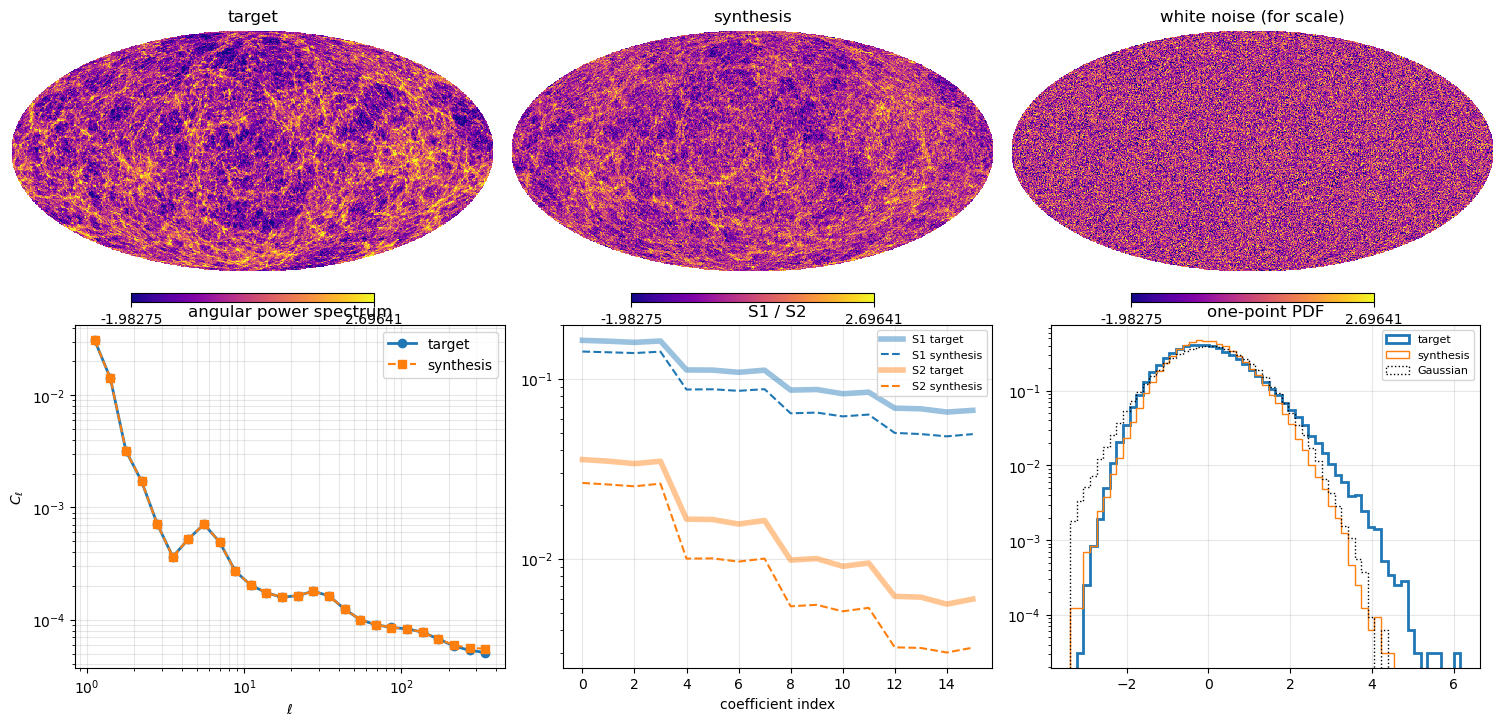

In [20]:
vmin, vmax = np.percentile(sky, [1, 99])

plt.figure(figsize=(15, 8))
hp.mollview(sky, nest=True, sub=(2, 3, 1), title="target", cmap="plasma",
            min=vmin, max=vmax, hold=False)
hp.mollview(synth, nest=True, sub=(2, 3, 2), title="synthesis", cmap="plasma",
            min=vmin, max=vmax, hold=False)
hp.mollview(noise, nest=True, sub=(2, 3, 3), title="white noise (for scale)",
            cmap="plasma", min=vmin, max=vmax, hold=False)

plt.subplot(2, 3, 4)
ell = cs_check.bin_centers.cpu().numpy()
plt.loglog(ell, ps_target, "o-", lw=2, label="target")
plt.loglog(ell, ps_synth, "s--", label="synthesis")
plt.xlabel(r"$\ell$"); plt.ylabel(r"$C_\ell$")
plt.legend(); plt.grid(alpha=.3, which="both"); plt.title("angular power spectrum")

plt.subplot(2, 3, 5)
for name, colour in (("S1", "C0"), ("S2", "C1")):
    a = getattr(st_target, name)[0, 0, 0].real.flatten().cpu().numpy()
    b = getattr(st_synth, name)[0, 0, 0].real.flatten().cpu().numpy()
    plt.plot(a, "-", color=colour, lw=4, alpha=.45, label=name + " target")
    plt.plot(b, "--", color=colour, label=name + " synthesis")
plt.yscale("log"); plt.legend(fontsize=8); plt.grid(alpha=.3)
plt.xlabel("coefficient index"); plt.title("S1 / S2")

plt.subplot(2, 3, 6)
bins = np.linspace(min(sky.min(), synth.min()), max(sky.max(), synth.max()), 60)
plt.hist(sky, bins=bins, histtype="step", density=True, lw=2, label="target")
plt.hist(synth, bins=bins, histtype="step", density=True, label="synthesis")
plt.hist(noise, bins=bins, histtype="step", density=True, ls=":", color="k",
         label="Gaussian")
plt.yscale("log"); plt.legend(fontsize=8); plt.grid(alpha=.3)
plt.title("one-point PDF")
plt.tight_layout(); plt.show()

### Explicit dyadic HEALPix pyramid

This is the large-map synthesis path.  The optimization variable is a
Laplacian HEALPix pyramid, not a full-resolution tensor attached to one global
autograd graph.  Each ScatCov coefficient is evaluated at its native
`j_to_dg` resolution.  Its VJP starts at that resolution and is propagated by
the explicit adjoints of the wavelet, modulus, covariance, downsampling and
pyramid reconstruction operators.

Coefficient batches never mix native resolutions.  Once one batch has
contributed to the loss and to the gradient maps of its level, its temporary
first- and second-layer S3/S4 fields are released.  `strategy="recompute"`
recomputes the minimum forward state needed by the reverse pass instead of
retaining it.  The persistent pyramid contains approximately `4/3 * Npix`
pixels; no `loss.backward()` or `torch.autograd.grad()` is used by this path.

`coefficient_batch_size` controls how many coefficients at one resolution are
live together.  It is the relevant memory/time control here; it is unrelated
to spatial patches.


In [ ]:
from STL_main.LossOptim import (
    PyramidOptimizer,
    PyramidSynthesis,
    SquaredStatisticsLoss,
)
from STL_main.Pyramid import HealpixPyramid

sky = heal_im
target = DataClass(sky)
J, L, KERNELSZ = int(np.log2(NSIDE)) - 1, 4, 5
COEFFICIENT_BATCH_SIZE = 16
NITER = 20  # memory smoke test; use at least 200 iterations for quality

print("J / L / kernel size:", J, L, KERNELSZ)

# The reference and the running pyramid must share this exact operator.  The
# explicit engine currently works on vanilla ScatCov coefficients; the fixed
# loss weights below reproduce the reference S2 normalization and S3/S4
# emphasis without putting normalization operations in a global graph.
pyramid_op = target.get_ST_op(
    J=J,
    L=L,
    norm="vanilla",
    compute_PS=False,
    has_fewer_convolutions=False,
    wavelet_op_kwargs={
        "kernel_size": KERNELSZ,
        "pyramid_pixel_batch_size": 16384,
    },
)

target_pyramid = HealpixPyramid.from_map(target, pyramid_op.wavelet_op)
target_stats = pyramid_op.apply_pyramid(
    target_pyramid,
    coefficient_batch_size=COEFFICIENT_BATCH_SIZE,
    strategy="recompute",
)


def reference_loss_weights(stats, s3_weight=3.5, s4_weight=3.5**2):
    """Squared-loss weights equivalent to STL's S2 reference normalization."""
    eps = torch.finfo(stats.values.real.dtype).eps
    sqrt_s2 = {}
    for index, coefficient in enumerate(stats.plan):
        if coefficient.family == "S2" and coefficient.c1 == coefficient.c2:
            sqrt_s2[(coefficient.c1, coefficient.j1, coefficient.l1)] = (
                stats.values[:, index].real.clamp_min(eps).sqrt()
            )

    weights = torch.ones_like(stats.values.real)
    for index, coefficient in enumerate(stats.plan):
        if coefficient.family == "S1":
            scale = (
                sqrt_s2[(coefficient.c1, coefficient.j1, coefficient.l1)]
                * sqrt_s2[(coefficient.c2, coefficient.j1, coefficient.l1)]
            ).sqrt()
        elif coefficient.family == "S2":
            scale = (
                sqrt_s2[(coefficient.c1, coefficient.j1, coefficient.l1)]
                * sqrt_s2[(coefficient.c2, coefficient.j1, coefficient.l1)]
            )
        elif coefficient.family == "S3":
            scale = (
                sqrt_s2[(coefficient.c1, coefficient.j1, coefficient.l1)]
                * sqrt_s2[(coefficient.c2, coefficient.j3, coefficient.l3)]
            )
        elif coefficient.family == "S4":
            scale = (
                sqrt_s2[(coefficient.c1, coefficient.j1, coefficient.l1)]
                * sqrt_s2[(coefficient.c2, coefficient.j2, coefficient.l2)]
            )
        else:
            continue
        weights[:, index] = scale.square().clamp_min(eps).reciprocal()
        if coefficient.family == "S3":
            weights[:, index].mul_(s3_weight**2)
        elif coefficient.family == "S4":
            weights[:, index].mul_(s4_weight**2)
    return weights


loss = SquaredStatisticsLoss(reference_loss_weights(target_stats))
solver = PyramidSynthesis(
    pyramid_op,
    target_stats,
    optimizer=PyramidOptimizer(lr=2e-2, method="adam"),
    loss=loss,
    coefficient_batch_size=COEFFICIENT_BATCH_SIZE,
    strategy="recompute",
)
running_pyramid = solver.initialize_from_noise(target, seed=26)

if target.device.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats(target.device)


def report(iteration, value):
    if iteration == 0 or (iteration + 1) % 10 == 0 or iteration + 1 == NITER:
        print(f"[pyramid/adam] iter {iteration + 1}/{NITER}, loss = {value:.6e}")


loss_history = solver.run(running_pyramid, niter=NITER, callback=report)
pyramid_synth = solver.reconstruct().squeeze().detach().cpu().numpy()

pyramid_pixels = sum(level.shape[-1] for level in running_pyramid.levels)
print("pyramid levels:", [level.shape[-1] for level in running_pyramid.levels])
print("stored pyramid pixels / full-sky pixels:", pyramid_pixels, "/", NPIX)
print("last loss:", loss_history[-1])
if target.device.type == "cuda":
    print(
        "CUDA peak allocated/reserved [MiB]:",
        torch.cuda.max_memory_allocated(target.device) / 2**20,
        torch.cuda.max_memory_reserved(target.device) / 2**20,
    )
assert np.isfinite(pyramid_synth).all()


## Summary

Certified by this notebook:

| | status |
|---|---|
| data class conforming to `Base_DataClass` | OK |
| wavelet convolution and anti-aliased HEALPix downsampling | OK |
| S1–S4 forward reference implementation | OK |
| explicit S1–S4 pyramid forward and VJP | experimental |
| Laplacian HEALPix synthesis variables | experimental |
| gradients beginning at each coefficient's native `j_to_dg` level | experimental |
| explicit adjoints without a global PyTorch autograd graph | experimental |
| coefficient batches released between native-resolution groups | experimental |
| angular power spectrum (`HEALPixSHT`) | OK |
| partial-sky statistics and masks in the legacy path | OK |

The explicit pyramid engine currently targets finite, unmasked HEALPix maps
and ScatCov without the power spectrum.  The legacy `ST_Operator.apply` remains
the scientific reference used by the small-map equivalence and gradient tests.
